# Демонстрация работы модели AI Moderator Bot

Этот ноутбук показывает полный демонстрационный сценарий для проекта: загрузка датасета, небольшой EDA-анализ, загрузка обученной модели и проверка сообщений на классы `normal`, `spam`, `profanity`.

Ноутбук рассчитан на запуск из папки `notebooks/` внутри проекта.

## 1. Подготовка окружения

Если ноутбук запускается из папки `notebooks/`, добавляем корень проекта в `sys.path`, чтобы Python видел модули из `src/`.

In [65]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

PROJECT_ROOT

PosixPath('/Users/vladimirfilimonov/PycharmProjects/Artificial_Intelligence_Engineering_2025-26/project')

## 2. Загрузка датасета

В проекте используется единый датасет `messages.csv` с двумя колонками:

- `text` — текст сообщения;
- `label` — класс сообщения: `normal`, `spam`, `profanity`.

In [66]:
import pandas as pd

DATASET_PATH = PROJECT_ROOT / "data" / "raw" / "messages.csv"

if not DATASET_PATH.exists():
    DATASET_PATH = PROJECT_ROOT / "data" / "messages.csv"

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        "Не найден датасет. Ожидаемый путь: data/raw/messages.csv или data/messages.csv"
    )

df = pd.read_csv(DATASET_PATH, sep=";", encoding="utf-8-sig")
df.head()

,text,label
0,"Привет, во сколько сегодня встречаемся?",normal
1,"Коллеги, отправил файл с отчётом в общий чат.",normal
2,"Спасибо за помощь, всё получилось.",normal
3,"Завтра пара начинается в 10:30, не опаздывайте.",normal
4,Кто может объяснить последнюю задачу по матема...,normal


## 3. Быстрая проверка данных

In [67]:
print("Размер датасета:", df.shape)
print("Колонки:", list(df.columns))
print("Пропуски:")
print(df.isna().sum())
print("Распределение классов:")
print(df["label"].value_counts())

Размер датасета: (41130, 2)
Колонки: ['text', 'label']
Пропуски:
text     0
label    0
dtype: int64
Распределение классов:
label
normal       23767
spam         16046
profanity     1317
Name: count, dtype: int64


<Axes: title={'center': 'Распределение классов'}, xlabel='label'>

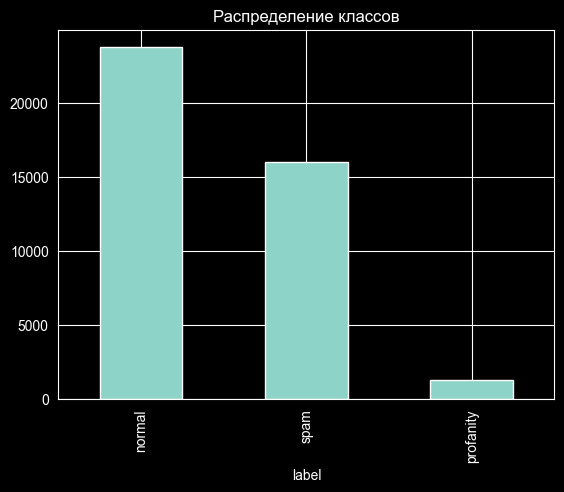

In [68]:
df["label"].value_counts().plot(kind="bar", title="Распределение классов")

## 4. Примеры сообщений из каждого класса

In [69]:
for label in sorted(df["label"].unique()):
    print(f"Класс: {label}")
    display(df[df["label"] == label][["text", "label"]].head(5))

Класс: normal


,text,label
0,"Привет, во сколько сегодня встречаемся?",normal
1,"Коллеги, отправил файл с отчётом в общий чат.",normal
2,"Спасибо за помощь, всё получилось.",normal
3,"Завтра пара начинается в 10:30, не опаздывайте.",normal
4,Кто может объяснить последнюю задачу по матема...,normal


Класс: profanity


,text,label
1146,анус,profanity
1147,аборт,profanity
1148,бздун,profanity
1149,беспезды,profanity
1150,бздюх,profanity


Класс: spam


,text,label
100,"Может кому-то нужен курс по ии и криптовалюте,...",spam
101,Ищy людeй для зaработка нa yдаленной оcнове в ...,spam
102,Ищy людeй для зaработка нa yдаленной оcнове в ...,spam
103,"В поиске людей, заинтересованных в получении х...",spam
104,Привет ребята! За годы самообразования накопил...,spam


## 5. Загрузка обученной модели

Модель должна быть предварительно обучена командой:

```bash
uv run python -m src.train
```

После обучения файл модели должен находиться в `artifacts/models/message_classifier.joblib`.

In [70]:
MODEL_PATH = PROJECT_ROOT / "artifacts" / "models" / "message_classifier.joblib"

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        "Модель не найдена. Сначала запусти из корня проекта: uv run python -m src.train"
    )

MODEL_PATH

PosixPath('/Users/vladimirfilimonov/PycharmProjects/Artificial_Intelligence_Engineering_2025-26/project/artifacts/models/message_classifier.joblib')

In [71]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.predict import MessageClassifier

classifier = MessageClassifier(MODEL_PATH)
print("Модель успешно загружена")

Модель успешно загружена


## 6. Проверка модели на тестовых сообщениях

In [72]:
test_messages = [
    "Привет, во сколько сегодня встречаемся?",
    "Ребята, кто идет завтра на пару?",
    "Заработок от 5000 рублей в день без опыта, пиши в личку",
    "Скидки 90 процентов, переходи по ссылке прямо сейчас",
    "Ты дурак",
    "Я недавно проводила урок для своего ученика",
]

results = [classifier.predict(message) for message in test_messages]
results_df = pd.DataFrame(results)
results_df[["text", "label", "confidence", "is_violation", "recommended_action"]]

,text,label,confidence,is_violation,recommended_action
0,"Привет, во сколько сегодня встречаемся?",normal,0.8815,False,allow
1,"Ребята, кто идет завтра на пару?",normal,0.4893,False,allow
2,"Заработок от 5000 рублей в день без опыта, пиш...",spam,1.0000,True,mute_user
3,"Скидки 90 процентов, переходи по ссылке прямо ...",spam,0.6729,True,delete_message
4,Ты дурак,profanity,0.7370,True,delete_message
5,Я недавно проводила урок для своего ученика,normal,0.5652,False,allow


## 7. Вероятности по классам

В этом блоке видно, насколько уверенно модель относит каждое сообщение к одному из классов.

In [73]:
probabilities_df = pd.DataFrame([
    {
        "text": item["text"],
        **item["probabilities"],
    }
    for item in results
])

probabilities_df

,text,normal,profanity,spam
0,"Привет, во сколько сегодня встречаемся?",0.8815,0.0112,0.1073
1,"Ребята, кто идет завтра на пару?",0.4893,0.0407,0.4700
2,"Заработок от 5000 рублей в день без опыта, пиш...",0.0000,0.0000,1.0000
3,"Скидки 90 процентов, переходи по ссылке прямо ...",0.2628,0.0643,0.6729
4,Ты дурак,0.1835,0.7370,0.0795
5,Я недавно проводила урок для своего ученика,0.5652,0.0462,0.3885


<Axes: title={'center': 'Вероятности классов для тестовых сообщений'}, xlabel='text'>

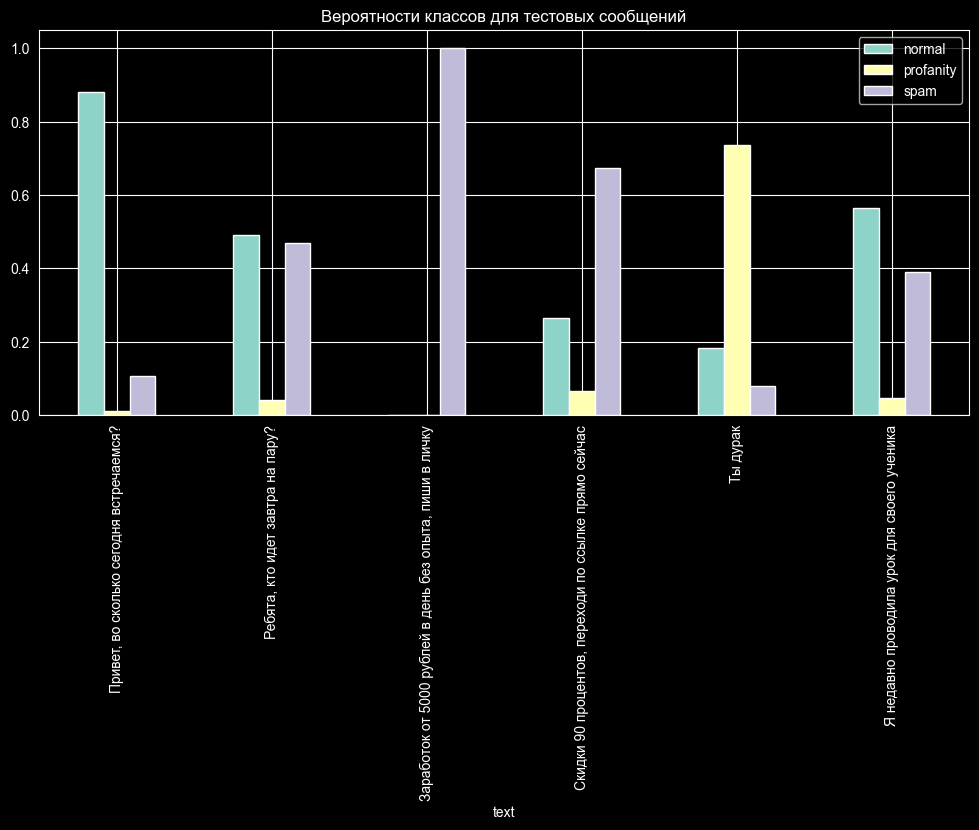

In [74]:
plot_df = probabilities_df.set_index("text")
plot_df.plot(kind="bar", figsize=(12, 5), title="Вероятности классов для тестовых сообщений")

## 8. Функция для ручной проверки сообщения

Можно заменить текст в переменной `message` и повторно выполнить ячейку.

In [75]:
message = "Привет, как дела?"

prediction = classifier.predict(message)
prediction

{'text': 'Привет, как дела?',
 'label': 'normal',
 'confidence': 0.9585,
 'is_violation': False,
 'recommended_action': 'allow',
 'probabilities': {'normal': 0.9585, 'profanity': 0.0108, 'spam': 0.0307}}

## 9. Интерпретация результата

Поле `label` показывает предсказанный класс сообщения.

Поле `is_violation` показывает, считается ли сообщение нарушением.

Поле `recommended_action` показывает рекомендуемое действие для бота:

- `allow` — пропустить сообщение;
- `delete_message` — удалить сообщение;
- `mute_user` — временно ограничить пользователя;
- `send_to_manual_review` — отправить сообщение на ручную проверку.

В рамках защиты этот ноутбук можно использовать как демонстрацию EDA, проверки модели и объяснения логики модерации.